# TMDB 5000 Movies — Data Analysis Project

**Goal:** Analyze the TMDB 5000 movie dataset, clean it, and generate meaningful summary statistics and insights.

**Dataset:** [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata) (Kaggle)
- `tmdb_5000_movies.csv` — budget, revenue, genres, ratings, release info
- `tmdb_5000_credits.csv` — cast and crew

**Steps covered:**
1. Load data with Pandas
2. Clean the data (missing values, data types, nested JSON fields)
3. Filter and group data
4. Generate insights
5. Visualize key findings


## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", 50)


ModuleNotFoundError: No module named 'matplotlib'

## 2. Load the Data

In [2]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)
movies.head(3)


Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [3]:
movies.info()


<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

## 3. Merge Movies and Credits

Both files share movie titles/ids, so we merge them into a single dataframe for analysis.

In [4]:
credits_renamed = credits.rename(columns={"movie_id": "id"})
df = movies.merge(credits_renamed[["id", "cast", "crew"]], on="id", how="left")
print("Merged shape:", df.shape)
df.head(3)


Merged shape: (4803, 22)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## 4. Data Cleaning

We'll:
- Parse the nested JSON-like columns (`genres`, `keywords`, `production_companies`, `cast`, `crew`) into readable lists/names
- Convert `release_date` to datetime and extract `release_year`
- Treat `budget` and `revenue` values of 0 as missing (unknown), since a $0 budget/revenue is not realistic
- Drop exact duplicate rows
- Extract the director's name from the crew field


In [5]:
def parse_names(json_str, key="name"):
    """Parse a JSON-like string column into a list of names."""
    try:
        items = ast.literal_eval(json_str)
        return [item[key] for item in items]
    except (ValueError, SyntaxError, TypeError):
        return []

for col in ["genres", "keywords", "production_companies", "production_countries", "spoken_languages"]:
    df[col] = df[col].apply(parse_names)

df["cast"] = df["cast"].apply(lambda x: parse_names(x)[:5])  # top 5 billed cast

def get_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str)
        for member in crew:
            if member.get("job") == "Director":
                return member.get("name")
    except (ValueError, SyntaxError, TypeError):
        pass
    return np.nan

df["director"] = df["crew"].apply(get_director)
df.drop(columns=["crew"], inplace=True)

df[["title", "genres", "cast", "director"]].head(5)


,title,genres,cast,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",James Cameron
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",Gore Verbinski
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",Sam Mendes
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[Christian Bale, Michael Caine, Gary Oldman, A...",Christopher Nolan
4,John Carter,"[Action, Adventure, Science Fiction]","[Taylor Kitsch, Lynn Collins, Samantha Morton,...",Andrew Stanton


In [6]:
# Dates and derived year
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# Treat 0 budget/revenue as missing (unknown), not actually zero
df["budget"] = df["budget"].replace(0, np.nan)
df["revenue"] = df["revenue"].replace(0, np.nan)
df["runtime"] = df["runtime"].replace(0, np.nan)

# Drop duplicate rows
before = len(df)
df = df.drop_duplicates(subset=["id"])
print(f"Dropped {before - len(df)} duplicate rows")

# Missing value summary
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Dropped 0 duplicate rows


homepage        3091
revenue         1427
budget          1037
tagline          844
runtime           37
director          30
overview           3
release_date       1
release_year       1
dtype: int64

In [7]:
# Profit and ROI, only computable where both budget and revenue are known
df["profit"] = df["revenue"] - df["budget"]
df["roi"] = df["profit"] / df["budget"]

df[["title", "budget", "revenue", "profit", "roi"]].dropna().sort_values("profit", ascending=False).head(5)


,title,budget,revenue,profit,roi
0,Avatar,237000000.0,2.787965e+09,2.550965e+09,10.763566
25,Titanic,200000000.0,1.845034e+09,1.645034e+09,8.225171
28,Jurassic World,150000000.0,1.513529e+09,1.363529e+09,9.090192
44,Furious 7,190000000.0,1.506249e+09,1.316249e+09,6.927628
16,The Avengers,220000000.0,1.519558e+09,1.299558e+09,5.907081


## 5. Filtering and Grouping

### 5.1 Filter: movies with reliable financial data (known budget & revenue) and enough votes

In [8]:
financial_df = df.dropna(subset=["budget", "revenue"])
reliable_df = df[df["vote_count"] >= 50]  # filter out movies with too few ratings to be meaningful

print(f"Movies with known budget & revenue: {len(financial_df)} / {len(df)}")
print(f"Movies with >= 50 votes: {len(reliable_df)} / {len(df)}")


Movies with known budget & revenue: 3229 / 4803
Movies with >= 50 votes: 3652 / 4803


### 5.2 Group: average rating and count by genre

In [2]:
genre_exploded = df.explode("genres")
genre_stats = (
    genre_exploded.groupby("genres")
    .agg(avg_rating=("vote_average", "mean"), num_movies=("id", "count"), avg_popularity=("popularity", "mean"))
    .sort_values("num_movies", ascending=False)
)
genre_stats.round(2).head(15)


NameError: name 'df' is not defined

### 5.3 Group: total & average revenue by release year

In [3]:
yearly_stats = (
    df.dropna(subset=["release_year", "revenue"])
    .groupby("release_year")
    .agg(total_revenue=("revenue", "sum"), avg_revenue=("revenue", "mean"), num_movies=("id", "count"))
)
yearly_stats.tail(15).round(0)


NameError: name 'df' is not defined

### 5.4 Group: top directors by average rating (min 3 movies)

In [4]:
director_stats = (
    df.dropna(subset=["director"])
    .groupby("director")
    .agg(avg_rating=("vote_average", "mean"), num_movies=("id", "count"))
)
top_directors = director_stats[director_stats["num_movies"] >= 3].sort_values("avg_rating", ascending=False)
top_directors.round(2).head(10)


NameError: name 'df' is not defined

## 6. Generate Insights

### 6.1 Top 10 highest-rated movies (with enough votes to be meaningful)

In [12]:
top_rated = reliable_df.sort_values("vote_average", ascending=False)[
    ["title", "vote_average", "vote_count", "release_year"]
].head(10)
top_rated


,title,vote_average,vote_count,release_year
1881,The Shawshank Redemption,8.5,8205,1994.0
3337,The Godfather,8.4,5893,1972.0
662,Fight Club,8.3,9413,1999.0
1818,Schindler's List,8.3,4329,1993.0
2731,The Godfather: Part II,8.3,3338,1974.0
2294,Spirited Away,8.3,3840,2001.0
3232,Pulp Fiction,8.3,8428,1994.0
3865,Whiplash,8.3,4254,2014.0
690,The Green Mile,8.2,4048,1999.0
3057,American History X,8.2,3016,1998.0


### 6.2 Top 10 most profitable movies

In [13]:
most_profitable = financial_df.sort_values("profit", ascending=False)[
    ["title", "budget", "revenue", "profit", "release_year"]
].head(10)
most_profitable


,title,budget,revenue,profit,release_year
0,Avatar,237000000.0,2.787965e+09,2.550965e+09,2009.0
25,Titanic,200000000.0,1.845034e+09,1.645034e+09,1997.0
28,Jurassic World,150000000.0,1.513529e+09,1.363529e+09,2015.0
44,Furious 7,190000000.0,1.506249e+09,1.316249e+09,2015.0
16,The Avengers,220000000.0,1.519558e+09,1.299558e+09,2012.0
7,Avengers: Age of Ultron,280000000.0,1.405404e+09,1.125404e+09,2015.0
124,Frozen,150000000.0,1.274219e+09,1.124219e+09,2013.0
546,Minions,74000000.0,1.156731e+09,1.082731e+09,2015.0
329,The Lord of the Rings: The Return of the King,94000000.0,1.118889e+09,1.024889e+09,2003.0
31,Iron Man 3,200000000.0,1.215440e+09,1.015440e+09,2013.0


### 6.3 Correlation between budget, revenue, popularity, and rating

In [14]:
corr_cols = ["budget", "revenue", "popularity", "vote_average", "vote_count", "runtime"]
correlation = df[corr_cols].corr()
correlation.round(2)


,budget,revenue,popularity,vote_average,vote_count,runtime
budget,1.00,0.71,0.46,0.02,0.56,0.26
revenue,0.71,1.00,0.61,0.18,0.76,0.23
popularity,0.46,0.61,1.00,0.27,0.78,0.22
vote_average,0.02,0.18,0.27,1.00,0.31,0.34
vote_count,0.56,0.76,0.78,0.31,1.00,0.28
runtime,0.26,0.23,0.22,0.34,0.28,1.00


### 6.4 Most popular genres over time (movies produced per decade)

In [15]:
df["decade"] = (df["release_year"] // 10 * 10)
genre_decade = genre_exploded.assign(decade=(genre_exploded["release_year"] // 10 * 10))
top_genres_overall = genre_stats.sort_values("num_movies", ascending=False).head(6).index.tolist()

genre_decade_counts = (
    genre_decade[genre_decade["genres"].isin(top_genres_overall)]
    .groupby(["decade", "genres"])
    .size()
    .unstack(fill_value=0)
)
genre_decade_counts.tail(8)


genres,Action,Adventure,Comedy,Drama,Romance,Thriller
decade,,,,,,
1940.0,2,1,1,16,8,2
1950.0,4,3,4,20,10,2
1960.0,17,14,15,42,13,15
1970.0,33,29,26,49,16,26
1980.0,84,75,82,100,37,71
1990.0,200,127,317,396,168,225
2000.0,467,320,809,1015,436,536
2010.0,345,218,461,646,195,396


### 6.5 Key takeaways

- **Ratings vs. votes:** filtering out low-vote-count movies is essential — a handful of votes can produce misleadingly high or low averages.
- **Budget vs. revenue:** the correlation table shows how strongly (or weakly) spending more on a movie relates to earning more back.
- **Genre landscape:** a small number of genres (Drama, Comedy, Action, Thriller) dominate the dataset in volume, but that doesn't always mean highest average rating.
- **Profitability outliers:** the most profitable movies are often not the most expensive ones — high ROI films tend to have modest budgets.


## 7. Visualizations

### 7.1 Distribution of movie ratings

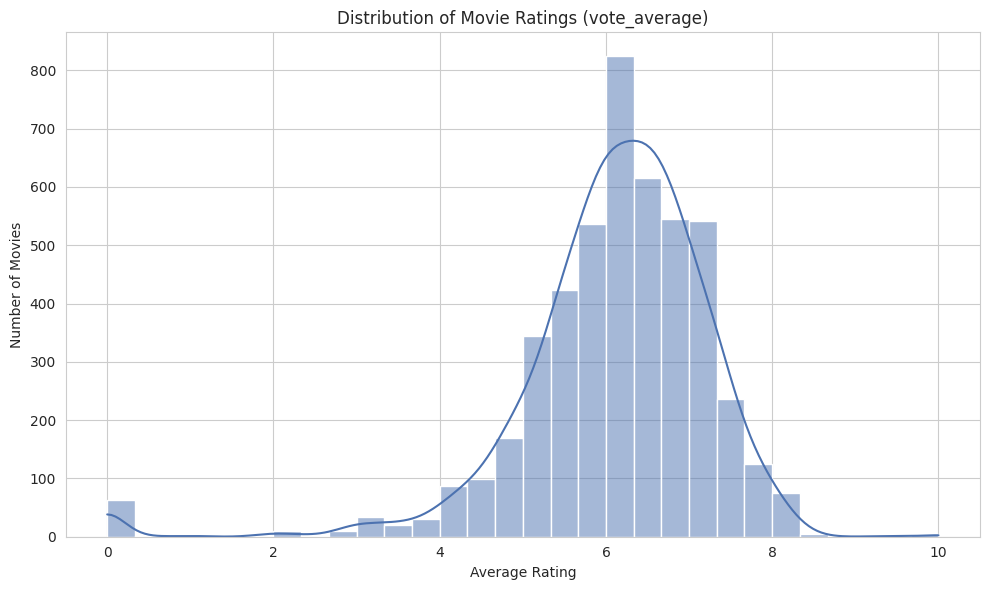

In [16]:
plt.figure()
sns.histplot(df["vote_average"].dropna(), bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of Movie Ratings (vote_average)")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


### 7.2 Budget vs. Revenue (log scale)

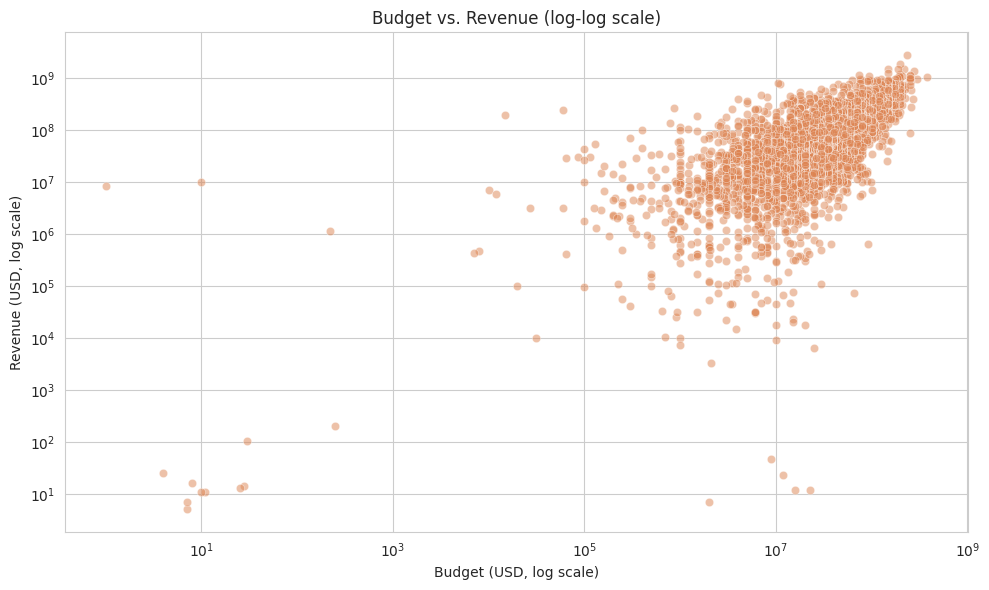

In [17]:
plt.figure()
sns.scatterplot(data=financial_df, x="budget", y="revenue", alpha=0.5, color="#DD8452")
plt.xscale("log")
plt.yscale("log")
plt.title("Budget vs. Revenue (log-log scale)")
plt.xlabel("Budget (USD, log scale)")
plt.ylabel("Revenue (USD, log scale)")
plt.tight_layout()
plt.show()


### 7.3 Top 10 genres by number of movies

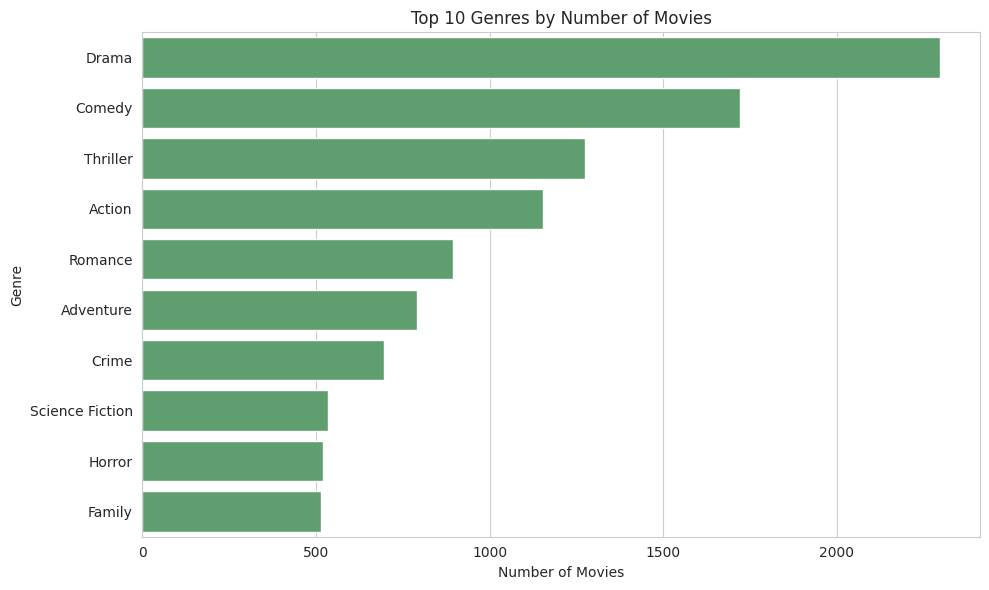

In [18]:
top10_genres = genre_stats.sort_values("num_movies", ascending=False).head(10)
plt.figure()
sns.barplot(x=top10_genres["num_movies"], y=top10_genres.index, color="#55A868")
plt.title("Top 10 Genres by Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


### 7.4 Average revenue by release year

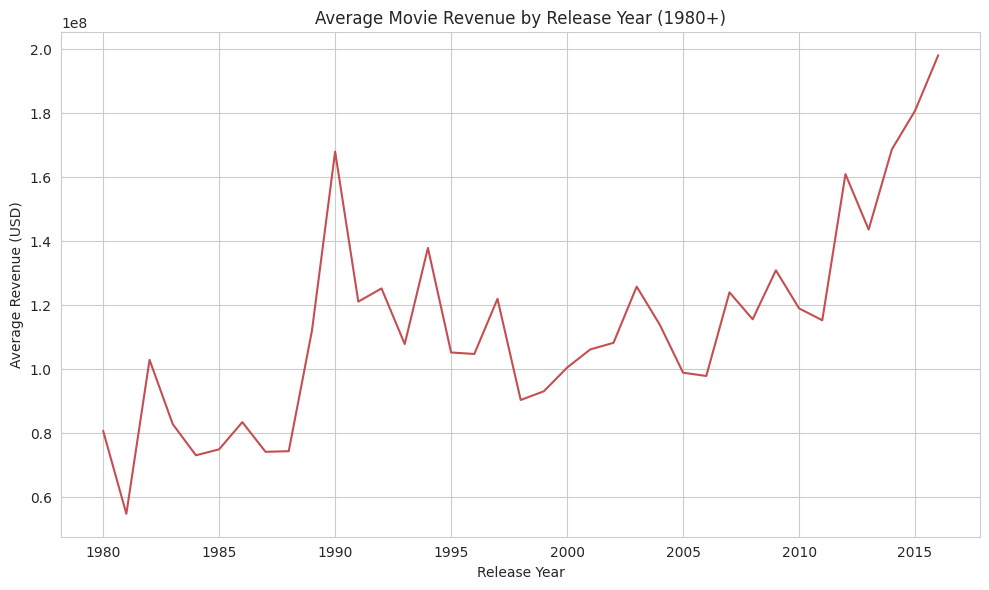

In [19]:
plt.figure()
yearly_recent = yearly_stats[yearly_stats.index >= 1980]
plt.plot(yearly_recent.index, yearly_recent["avg_revenue"], color="#C44E52")
plt.title("Average Movie Revenue by Release Year (1980+)")
plt.xlabel("Release Year")
plt.ylabel("Average Revenue (USD)")
plt.tight_layout()
plt.show()


### 7.5 Genre popularity trend by decade (top 6 genres)

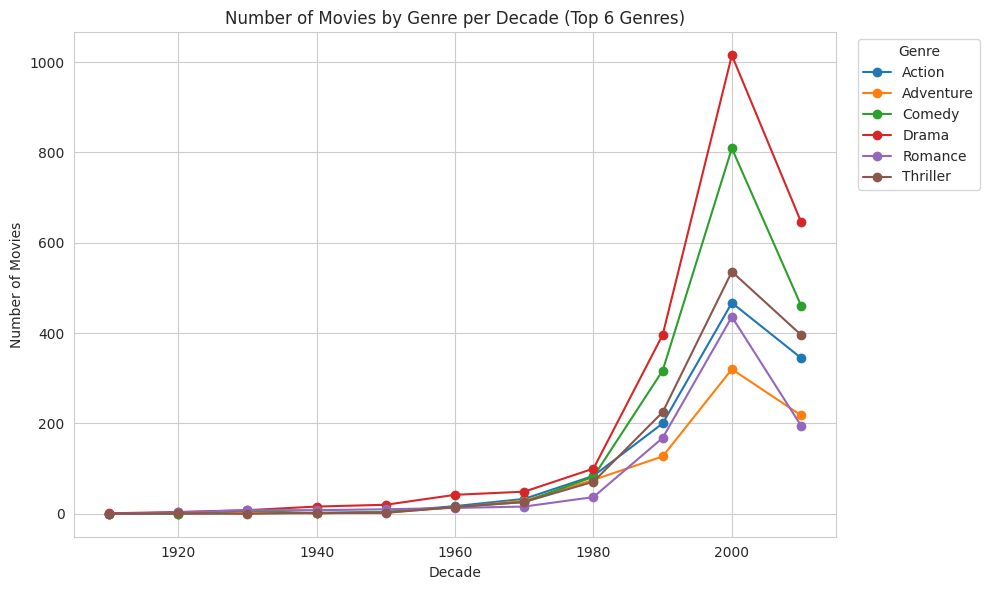

In [20]:
genre_decade_counts.plot(kind="line", marker="o")
plt.title("Number of Movies by Genre per Decade (Top 6 Genres)")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Conclusion

This analysis cleaned and explored the TMDB 5000 movie dataset, covering:
- Parsing nested JSON columns into usable fields (genres, cast, director)
- Handling missing/zero values in budget, revenue, and runtime
- Filtering to reliable subsets (enough votes, known financials)
- Grouping by genre, year, and director to summarize trends
- Visualizing distributions, relationships, and trends over time

Feel free to extend this notebook with further analysis, e.g. actor-level trends, seasonal release patterns, or predictive modeling of revenue.
